# Transformer 使用 PyTorch 高级 API 实现

本 notebook 使用 PyTorch 内置的 `nn.Transformer` 等高级 API 来实现 Transformer 模型，代码更简洁、性能更好。

In [10]:
import math
import time
import collections
import requests
import zipfile
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0+cu128


## 1. 设备选择

In [11]:
def try_gpu():
    """返回 GPU（如果可用），否则返回 CPU"""
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device = try_gpu()
print(f"Using device: {device}")

Using device: cuda


## 2. 词表类

In [12]:
class Vocab:
    """词表类：支持 token 到索引的双向映射"""
    
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        if reserved_tokens is None:
            reserved_tokens = []
        
        self.idx_to_token = ['<unk>'] + reserved_tokens + ['<bos>', '<eos>', '<pad>']
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        
        counter = collections.Counter()
        if tokens is not None:
            for token_list in tokens:
                counter.update(token_list)
        
        self._freqs = counter
        self.sorted_tokens = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        
        for token, freq in self.sorted_tokens:
            if freq >= min_freq and token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1
    
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self.__getitem__(token) for token in tokens]
    
    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[idx] for idx in indices]
    
    @property
    def unk(self):
        return 0
    
    @property
    def bos(self):
        return self.token_to_idx['<bos>']
    
    @property
    def eos(self):
        return self.token_to_idx['<eos>']
    
    @property
    def pad(self):
        return self.token_to_idx['<pad>']

## 3. 数据加载

In [13]:
def preprocess_nmt(text):
    """预处理英法翻译文本"""
    def no_space(char, prev_char):
        return char in set(',.!?') and prev_char != ' '
    
    # 替换非换行空格，转小写
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    # 在标点前插入空格
    out = []
    for i, char in enumerate(text):
        if i > 0 and no_space(char, text[i - 1]):
            out.append(' ' + char)
        else:
            out.append(char)
    return ''.join(out)


def tokenize_nmt(text, max_examples=None):
    """分词并返回源语言和目标语言列表"""
    source, target = [], []
    for i, line in enumerate(text.split('\n')):
        if max_examples and i > max_examples:
            break
        parts = line.split('\t')
        if len(parts) == 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target


def truncate_pad(line, num_steps, padding_token):
    """截断或填充序列到固定长度"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))


def build_array_nmt(lines, vocab, num_steps):
    """将文本序列转换为张量数组"""
    lines = [vocab[l] for l in lines]
    lines = [l + [vocab.eos] for l in lines]
    array = torch.tensor([truncate_pad(l, num_steps, vocab.pad) for l in lines])
    valid_len = (array != vocab.pad).sum(dim=1)
    return array, valid_len


def load_array(data_arrays, batch_size, is_train=True):
    """PyTorch 数据迭代器"""
    dataset = TensorDataset(*data_arrays)
    return DataLoader(dataset, batch_size, shuffle=is_train)


def load_data_nmt(batch_size, num_steps, num_examples=600):
    """加载英法翻译数据集（按照 d2l 的实现方式）"""
    import hashlib
    
    url = 'http://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip'
    
    # 数据目录
    data_dir = os.path.join(os.getcwd(), 'data', 'fra-eng')
    os.makedirs(data_dir, exist_ok=True)
    zip_path = os.path.join(os.path.dirname(data_dir), 'fra-eng.zip')
    
    # 下载数据
    if not os.path.exists(zip_path):
        print(f"Downloading {url}...")
        response = requests.get(url, timeout=30)
        os.makedirs(os.path.dirname(zip_path), exist_ok=True)
        with open(zip_path, 'wb') as f:
            f.write(response.content)
        print("Download complete.")
    
    # 解压数据
    if not os.path.exists(os.path.join(data_dir, 'fra.txt')):
        print("Extracting data...")
        with zipfile.ZipFile(zip_path, 'r') as fp:
            fp.extractall(os.path.dirname(data_dir))
        print("Extraction complete.")
    
    # 读取数据
    with open(os.path.join(data_dir, 'fra.txt'), 'r', encoding='utf-8') as f:
        text = f.read()
    
    # 预处理
    text = preprocess_nmt(text)
    source, target = tokenize_nmt(text, num_examples)
    
    # 构建词表
    src_vocab = Vocab(source, min_freq=2, reserved_tokens=['<pad>'])
    tgt_vocab = Vocab(target, min_freq=2, reserved_tokens=['<pad>'])
    
    print(f"源语言词表大小: {len(src_vocab)}, 目标语言词表大小: {len(tgt_vocab)}")
    
    # 构建数据数组
    src_array, src_valid_len = build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = build_array_nmt(target, tgt_vocab, num_steps)
    
    # 创建数据迭代器
    data_arrays = (src_array, src_valid_len, tgt_array, tgt_valid_len)
    train_iter = load_array(data_arrays, batch_size, is_train=True)
    
    return train_iter, src_vocab, tgt_vocab

## 4. 训练辅助类

In [14]:
class Timer:
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()
    
    def start(self):
        self.tik = time.time()
    
    def stop(self):
        self.times.append(time.time() - self.tik)
        return self.times[-1]


class Accumulator:
    """在 n 个变量上累加"""
    def __init__(self, n):
        self.data = [0.0] * n
    
    def add(self, *args):
        self.data = [a + float(b) for a, b in zip(self.data, args)]
    
    def __getitem__(self, idx):
        return self.data[idx]


class Animator:
    """使用 matplotlib 绘制训练进度"""
    def __init__(self, xlabel=None, ylabel=None, xlim=None, ylim=None,
                 legend=None, figsize=(5, 3)):
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.xlabel = xlabel
        self.ylabel = ylabel
        self.xlim = xlim
        self.ylim = ylim
        self.xscale = 'linear'
        self.yscale = 'linear'
        self.legend = legend
        self.x_data = []
        self.y_data = [] if legend is None else [[] for _ in legend]
    
    def add(self, x, y):
        if not hasattr(y, "__len__"):
            y = [y]
        n = len(y)
        if not hasattr(x, "__len__"):
            x = [x] * n
        
        self.x_data.extend(x)
        if self.legend is None:
            self.y_data.extend(y)
        else:
            for i, yi in enumerate(y):
                self.y_data[i].extend(yi)
        
        self.ax.cla()
        if self.xlabel:
            self.ax.set_xlabel(self.xlabel)
        if self.ylabel:
            self.ax.set_ylabel(self.ylabel)
        if self.xlim:
            self.ax.set_xlim(self.xlim)
        if self.ylim:
            self.ax.set_ylim(self.ylim)
        if self.legend is None:
            self.ax.plot(self.x_data, self.y_data)
        else:
            for i, (label, ys) in enumerate(zip(self.legend, self.y_data)):
                self.ax.plot(self.x_data[:len(ys)], ys, label=label)
            self.ax.legend()
        
        self.fig.canvas.draw()
        plt.pause(0.01)
    
    def show(self):
        plt.show()

## 5. 使用 PyTorch 高级 API 实现 Transformer

In [15]:
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # 创建位置编码矩阵
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        
        # 注册为 buffer，不参与梯度更新
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


def create_padding_mask(seq, pad_idx):
    """创建填充掩码
    
    Args:
        seq: (batch, seq_len)
        pad_idx: 填充 token 的索引
    
    Returns:
        (batch, seq_len) bool tensor, True 表示需要 mask
    """
    return (seq == pad_idx)


def create_causal_mask(seq_len, device):
    """创建因果掩码（解码器自注意力用）
    
    Args:
        seq_len: 序列长度
        device: 设备
    
    Returns:
        (seq_len, seq_len) float tensor
    """
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [16]:
class TransformerSeq2Seq(nn.Module):
    """使用 PyTorch nn.Transformer 的序列到序列模型
    
    使用 PyTorch 内置的高级 API:
    - nn.Transformer
    - nn.Embedding
    - 自定义位置编码
    """
    
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=512, nhead=8,
                 num_encoder_layers=6, num_decoder_layers=6,
                 dim_feedforward=2048, dropout=0.1, pad_idx=0):
        super(TransformerSeq2Seq, self).__init__()
        self.d_model = d_model
        self.pad_idx = pad_idx
        self.src_vocab_size = src_vocab_size
        self.tgt_vocab_size = tgt_vocab_size
        
        # 嵌入层
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=pad_idx)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=pad_idx)
        
        # 位置编码
        self.pos_encoding = PositionalEncoding(d_model, dropout)
        
        # PyTorch Transformer (batch_first=True 需要较新版本的 PyTorch)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # (batch, seq, feature) 格式
        )
        
        # 输出生成器
        self.generator = nn.Linear(d_model, tgt_vocab_size)
        
        # 初始化权重
        self._init_weights()
    
    def _init_weights(self):
        """初始化权重"""
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None, 
                 tgt_mask=None, memory_key_padding_mask=None):
        """前向传播
        
        Args:
            src: 源序列 (batch, src_len)
            tgt: 目标序列 (batch, tgt_len)
            src_key_padding_mask: 源序列填充掩码 (batch, src_len)
            tgt_key_padding_mask: 目标序列填充掩码 (batch, tgt_len)
            tgt_mask: 目标序列因果掩码 (tgt_len, tgt_len)
            memory_key_padding_mask: 记忆填充掩码 (batch, src_len)
        
        Returns:
            输出 logits (batch, tgt_len, tgt_vocab_size)
        """
        # 嵌入 + 位置编码
        src = self.pos_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt = self.pos_encoding(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        
        # Transformer
        outs = self.transformer(
            src, tgt,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            tgt_mask=tgt_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        
        return self.generator(outs)
    
    def encode(self, src, src_key_padding_mask=None):
        """编码（用于预测）"""
        src = self.pos_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        memory = self.transformer.encoder(src, src_key_padding_mask=src_key_padding_mask)
        return memory
    
    def decode(self, tgt, memory, tgt_mask=None, tgt_key_padding_mask=None,
                memory_key_padding_mask=None):
        """解码（用于预测）"""
        tgt = self.pos_encoding(self.tgt_embedding(tgt) * math.sqrt(self.d_model))
        outs = self.transformer.decoder(
            tgt, memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask
        )
        return self.generator(outs)

## 6. 训练函数

In [17]:
def masked_softmax_ce_loss(pred, label, pad_idx):
    """带掩码的交叉熵损失
    
    Args:
        pred: (batch, tgt_len, vocab_size)
        label: (batch, tgt_len)
        pad_idx: 填充 token 索引
    
    Returns:
        (batch,) 每个样本的平均损失
    """
    # pred: (B, T, V) -> (B, V, T) for CrossEntropyLoss
    pred = pred.permute(0, 2, 1)
    
    # 计算损失，不进行归约
    loss = F.cross_entropy(pred, label, reduction='none')  # (batch, tgt_len)
    
    # 创建掩码：非填充位置为 1.0，填充位置为 0.0
    mask = (label != pad_idx).float()  # (batch, tgt_len)
    
    # 应用掩码
    loss = loss * mask  # (batch, tgt_len)
    
    # 每个样本的平均损失（只计算有效 token）
    # loss.sum(dim=1) 是 (batch,)，mask.sum(dim=1) 也是 (batch,)
    loss = loss.sum(dim=1) / (mask.sum(dim=1) + 1e-8)
    
    return loss


def train_epoch(model, data_iter, optimizer, pad_idx, device):
    """训练一个 epoch"""
    model.train()
    metric = Accumulator(2)
    
    for batch in data_iter:
        optimizer.zero_grad()
        
        X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
        batch_size = X.shape[0]
        
        # 创建解码器输入（右移）
        bos = torch.tensor([pad_idx + 1] * batch_size, device=device).reshape(-1, 1)  # 使用 <bos>
        dec_input = torch.cat([bos, Y[:, :-1]], 1)
        
        # 创建填充掩码
        src_key_padding_mask = create_padding_mask(X, pad_idx).to(device)
        tgt_key_padding_mask = create_padding_mask(dec_input, pad_idx).to(device)
        
        # 创建因果掩码
        tgt_len = dec_input.shape[1]
        tgt_mask = create_causal_mask(tgt_len, device)
        
        # 前向传播
        Y_hat = model(X, dec_input, 
                      src_key_padding_mask=src_key_padding_mask,
                      tgt_key_padding_mask=tgt_key_padding_mask,
                      tgt_mask=tgt_mask,
                      memory_key_padding_mask=src_key_padding_mask)
        
        # 计算损失
        l = masked_softmax_ce_loss(Y_hat, Y, pad_idx)
        
        # 反向传播
        l.sum().backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        with torch.no_grad():
            metric.add(l.sum(), Y_valid_len.sum())
    
    return metric[0] / metric[1]


def train_seq2seq(model, data_iter, lr, num_epochs, pad_idx, device):
    """训练序列到序列模型"""
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    animator = Animator(xlabel='epoch', ylabel='loss', xlim=[1, num_epochs])
    
    for epoch in range(1, num_epochs + 1):
        timer = Timer()
        loss = train_epoch(model, data_iter, optimizer, pad_idx, device)
        
        animator.add(epoch, loss)
        
        if epoch % 10 == 0:
            print(f'Epoch {epoch}, loss: {loss:.4f}, time: {timer.stop():.2f}s')
    
    print(f'Training complete!')
    animator.show()

## 7. 模型训练

Using device: cuda
源语言词表大小: 185, 目标语言词表大小: 202

Model parameters: 738,634
Trainable parameters: 738,634


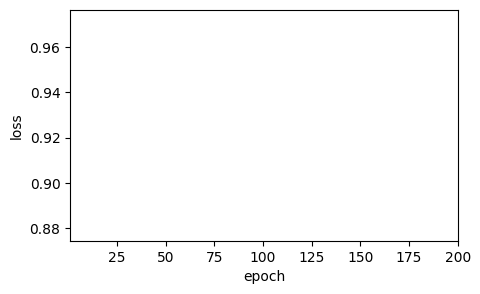

Epoch 10, loss: 0.5292, time: 0.21s
Epoch 20, loss: 0.4077, time: 0.21s
Epoch 30, loss: 0.3631, time: 0.22s
Epoch 40, loss: 0.3592, time: 0.21s
Epoch 50, loss: 0.3476, time: 0.21s
Epoch 60, loss: 0.3354, time: 0.21s
Epoch 70, loss: 0.3227, time: 0.21s
Epoch 80, loss: 0.3335, time: 0.22s
Epoch 90, loss: 0.3191, time: 0.22s
Epoch 100, loss: 0.3229, time: 0.22s
Epoch 110, loss: 0.3021, time: 0.21s
Epoch 120, loss: 0.2994, time: 0.21s
Epoch 130, loss: 0.2963, time: 0.22s
Epoch 140, loss: 0.2944, time: 0.24s
Epoch 150, loss: 0.2821, time: 0.21s
Epoch 160, loss: 0.2875, time: 0.21s
Epoch 170, loss: 0.2775, time: 0.21s
Epoch 180, loss: 0.2817, time: 0.22s
Epoch 190, loss: 0.2810, time: 0.22s
Epoch 200, loss: 0.2795, time: 0.22s
Training complete!


In [22]:
# ===== 超参数配置 =====
d_model = 128          # 模型维度
nhead = 4              # 注意力头数
num_encoder_layers = 2 # 编码器层数
num_decoder_layers = 2 # 解码器层数
dim_feedforward = 256  # 前馈网络隐藏层维度
dropout = 0.1          # Dropout 概率
batch_size = 64        # 批大小
num_steps = 10         # 序列最大长度
lr = 0.005             # 学习率
num_epochs = 200       # 训练轮数

device = try_gpu()
print(f"Using device: {device}")

# 加载数据
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

# 创建模型
model = TransformerSeq2Seq(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    pad_idx=src_vocab.pad
)

print(f"\nModel parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# 开始训练
train_seq2seq(model, train_iter, lr, num_epochs, src_vocab.pad, device)

## 8. 预测与 BLEU 评估

In [19]:
def predict_seq2seq(model, src_sentence, src_vocab, tgt_vocab, num_steps, device):
    """序列到序列预测（贪婪解码）
    
    Args:
        model: 训练好的模型
        src_sentence: 源句子字符串
        src_vocab: 源语言词表
        tgt_vocab: 目标语言词表
        num_steps: 最大生成长度
        device: 设备
    
    Returns:
        翻译结果字符串
    """
    model.eval()
    
    # 处理输入句子
    src_tokens = src_vocab[src_sentence.lower().split(' ')]
    src_tokens = src_tokens + [src_vocab.eos]
    
    # 截断或填充
    src_tokens = truncate_pad(src_tokens, num_steps, src_vocab.pad)
    
    # 转换为张量
    src = torch.tensor(src_tokens, dtype=torch.long, device=device).unsqueeze(0)
    
    # 编码
    src_key_padding_mask = create_padding_mask(src, src_vocab.pad).to(device)
    memory = model.encode(src, src_key_padding_mask=src_key_padding_mask)
    
    # 解码（贪婪解码）
    output = [tgt_vocab.bos]  # 从 <bos> 开始
    
    for _ in range(num_steps):
        tgt = torch.tensor(output, dtype=torch.long, device=device).unsqueeze(0)
        
        tgt_mask = create_causal_mask(len(output), device)
        tgt_key_padding_mask = create_padding_mask(tgt, tgt_vocab.pad).to(device)
        
        # 预测下一个 token
        logits = model.decode(
            tgt, memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )
        
        pred = logits.argmax(dim=-1)[:, -1].item()
        
        if pred == tgt_vocab.eos:
            break
        
        output.append(pred)
    
    # 转换为字符串
    translation = ' '.join(tgt_vocab.to_tokens(output[1:]))  # 跳过 <bos>
    return translation


def bleu(pred_seq, label_seq, k):
    """BLEU 评分计算"""
    pred_tokens, label_tokens = pred_seq.split(' '), label_seq.split(' ')
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    score = math.exp(min(0, 1 - len_label / len_pred))
    
    for n in range(1, min(k, len_pred) + 1):
        num_matches, label_subs = 0, collections.defaultdict(int)
        for i in range(len_label - n + 1):
            label_subs[' '.join(label_tokens[i: i + n])] += 1
        for i in range(len_pred - n + 1):
            if label_subs[' '.join(pred_tokens[i: i + n])] > 0:
                num_matches += 1
                label_subs[' '.join(pred_tokens[i: i + n])] -= 1
        score *= math.pow(num_matches / (len_pred - n + 1), math.pow(0.5, n))
    
    return score

In [20]:
# 测试翻译
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']

for eng, fra in zip(engs, fras):
    translation = predict_seq2seq(
        model, eng, src_vocab, tgt_vocab, num_steps, device)
    print(f'{eng} => {translation}, bleu {bleu(translation, fra, k=2):.3f}')

go . => !, bleu 0.368
i lost . => ., bleu 0.135
he's calm . => chiens aboient ., bleu 0.000
i'm home . => ., bleu 0.018
